# Benchmark: Slide-seq Brain Atlas

Slide-seq spatial transcriptomics data from a mouse brain atlas (101+ pucks).

Key metadata columns per bead (from README):
- `Raw_Slideseq_X`, `Raw_Slideseq_Y` — raw slide-seq coordinates (used here)
- `CCF_X/Y/Z` — Allen CCF-registered coordinates
- `TopStruct`, `DeepCCF`, `CCF_acronym` — brain region annotations
- `IsOutsideCCF` — bead falls outside CCF boundary (use for filtering)

In [12]:
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

DATA_DIR = Path('/lustre/scratch126/gengen/teams_v2/marks/dp31/SpatialPeeler/benchmark/All_Pucks_h5ad')
## check how many pucks we have
puck_files = list(DATA_DIR.glob('*.h5ad'))
print(f'Found {len(puck_files)} puck files.')
PUCK_IDS = [f'{i:02d}' for i in range(1, 10)]   # 01 – 10

Found 111 puck files.


In [ ]:
def load_puck_obs(puck_id):
    """Load a single puck keeping only obs (skips the large X matrix)."""
    path = DATA_DIR / f'Puck_Num_{puck_id}.h5ad'
    tmp = ad.read_h5ad(path, backed='r')
    obs = tmp.obs.copy()
    obs['puck_id'] = puck_id
    tmp.file.close()
    return obs

pucks = {pid: load_puck_obs(pid) for pid in PUCK_IDS}
print(f'Loaded {len(pucks)} pucks')
for pid, obs in pucks.items():
    print(f'  Puck {pid}: {len(obs):>7,} beads  |  TopStruct: {obs["TopStruct"].value_counts().to_dict()}')

Loaded 9 pucks
  Puck 01: 129,722 beads  |  TopStruct: {'NA': 68223, 'OLF': 31596, 'Isocortex': 23681, 'FB_VS_grey': 6222}
  Puck 02: 114,834 beads  |  TopStruct: {'NA': 58366, 'OLF': 28419, 'Isocortex': 23027, 'FB_VS_grey': 5022}
  Puck 03: 117,761 beads  |  TopStruct: {'NA': 54065, 'Isocortex': 35338, 'OLF': 25102, 'FB_VS_grey': 3256}
  Puck 04: 122,129 beads  |  TopStruct: {'Isocortex': 44983, 'NA': 44609, 'OLF': 29324, 'FB_VS_grey': 3213}
  Puck 05: 110,160 beads  |  TopStruct: {'NA': 42864, 'Isocortex': 39243, 'OLF': 25682, 'FB_VS_grey': 2371}
  Puck 06: 100,322 beads  |  TopStruct: {'Isocortex': 55999, 'OLF': 22060, 'NA': 20474, 'FB_VS_grey': 1789}
  Puck 07: 127,757 beads  |  TopStruct: {'Isocortex': 57203, 'NA': 41849, 'OLF': 26376, 'FB_VS_grey': 2329}
  Puck 08: 104,778 beads  |  TopStruct: {'Isocortex': 52670, 'NA': 28024, 'OLF': 22237, 'FB_VS_grey': 1847}
  Puck 09: 124,788 beads  |  TopStruct: {'NA': 56147, 'Isocortex': 47309, 'OLF': 19745, 'FB_VS_grey': 1587}


In [ ]:
len(pucks)

9

## Spatial maps

In [9]:
def plot_puck(obs, puck_id, color='TopStruct', point_size=0.3):
    obs = obs[obs['IsOutsideCCF'] == 0]   # keep only tissue-covered beads

    cats = sorted(obs[color].astype(str).unique(), key=lambda x: (x == 'NA', x))
    cmap = plt.colormaps['tab20'].resampled(len(cats))
    col_dict = {c: cmap(i) for i, c in enumerate(cats)}
    col_dict['NA'] = (0.82, 0.82, 0.82, 1.0)

    x = obs['Raw_Slideseq_X'].values.astype(float)
    y = obs['Raw_Slideseq_Y'].values.astype(float)
    c = [col_dict[str(v)] for v in obs[color]]

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(x, y, c=c, s=point_size, linewidths=0, edgecolors='none', rasterized=True)
    ax.set_aspect('equal', 'box')
    ax.axis('off')
    ax.set_title(f'Puck {puck_id} — {color}  (n={len(obs):,})', fontsize=10)

    patches = [mpatches.Patch(color=col_dict[c], label=c) for c in cats]
    ax.legend(handles=patches, fontsize=7, loc='lower right', frameon=False, markerscale=4)
    plt.tight_layout()
    plt.show()

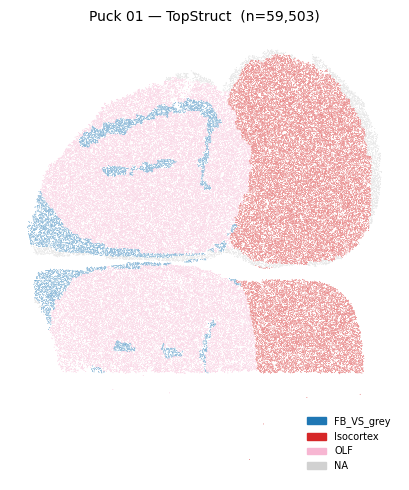

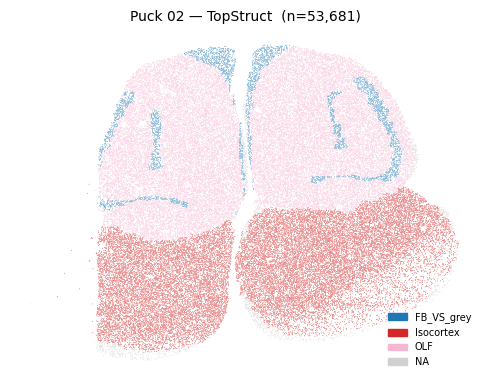

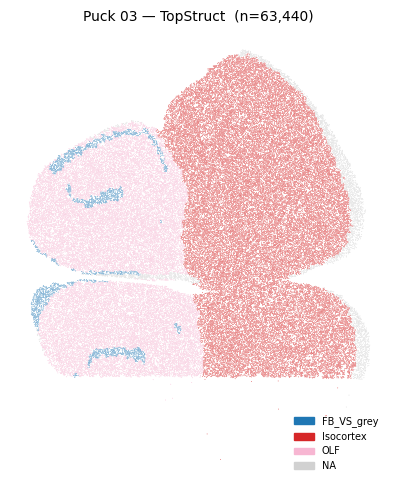

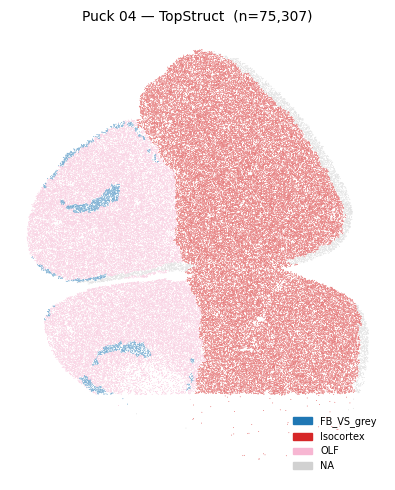

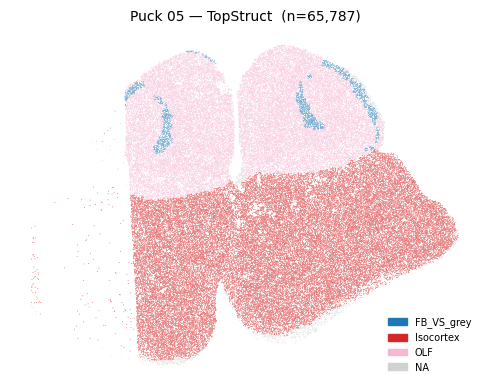

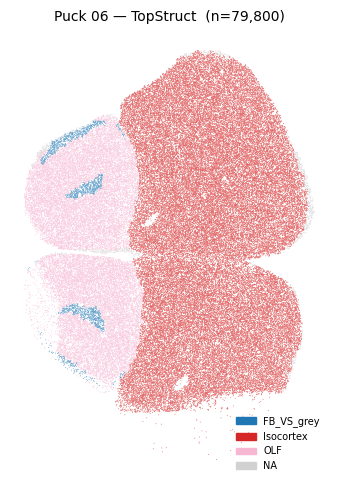

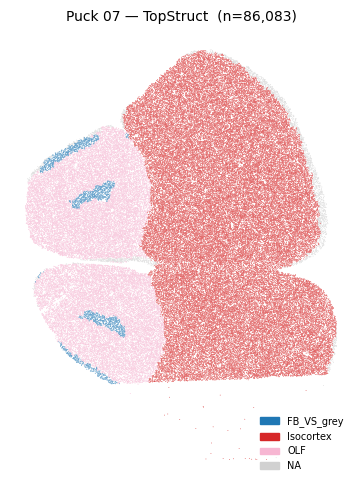

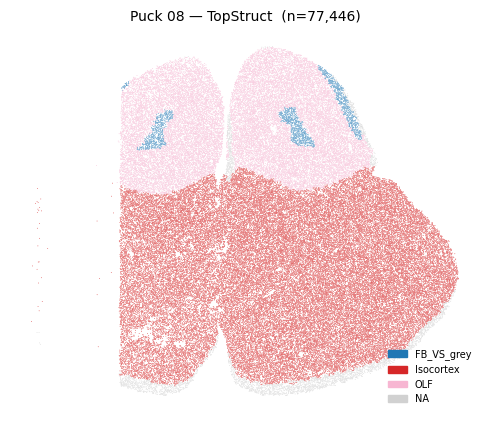

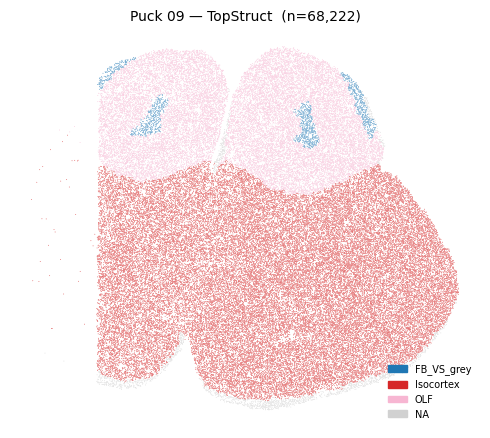

In [17]:
for pid in PUCK_IDS:
    plot_puck(pucks[pid], pid)

Top half:    34,390 beads
Bottom half: 45,410 beads


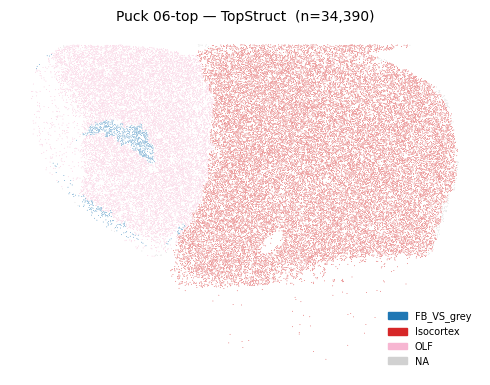

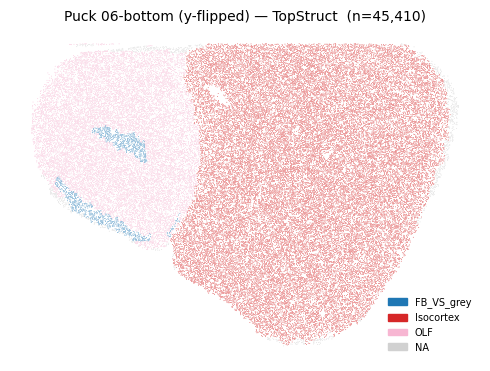

In [ ]:
obs06 = pucks['06'].copy()
obs06 = obs06[obs06['IsOutsideCCF'] == 0]

y = obs06['Raw_Slideseq_Y'].values.astype(float)

split_y = 2323.0   # midpoint of natural gap in Y distribution

obs06_top    = obs06[y <= split_y].copy()
obs06_bottom = obs06[y >  split_y].copy()

print(f'Top half:    {len(obs06_top):,} beads')
print(f'Bottom half: {len(obs06_bottom):,} beads')

# flip bottom half vertically so it overlays the top for comparison
y_bot = obs06_bottom['Raw_Slideseq_Y'].values.astype(float)
obs06_bottom = obs06_bottom.copy()
obs06_bottom['Raw_Slideseq_Y'] = y_bot.max() + y_bot.min() - y_bot

plot_puck(obs06_top,    '06-top')
plot_puck(obs06_bottom, '06-bottom (y-flipped)')

In [ ]:
# Find the natural split point in puck 06 by looking at the Y-axis bead density
obs06_all = pucks['06'][pucks['06']['IsOutsideCCF'] == 0].copy()
y_all = obs06_all['Raw_Slideseq_Y'].values.astype(float)

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(y_all, bins=100, color='steelblue', edgecolor='none')
ax.axvline(2323, color='red', linestyle='--', label='split at Y=2323')
ax.set_xlabel('Raw_Slideseq_Y')
ax.set_ylabel('Bead count')
ax.set_title('Puck 06 — Y coordinate distribution (two sections visible as two peaks)')
ax.legend()
plt.tight_layout()
plt.show()

Index(['nCount_Spatial', 'nFeature_Spatial', 'PuckID', 'Raw_Slideseq_X',
       'Raw_Slideseq_Y', 'Puck_Depth', 'nCount_Spatial.1',
       'nFeature_Spatial.1', 'CCF_X', 'CCF_Y', 'CCF_Z', 'TopStruct', 'DeepCCF',
       'CCF_acronym', 'CCF_ID', 'CCF_Name', 'CCF_LeftRight', 'IsOutsideCCF',
       'Correponding_DissectateSegName', 'Correponding_DissectateSegID',
       'NisslTiffX', 'NisslTiffY', 'BeadBarcode', '.id', 'orig.ident',
       'puck_id'],
      dtype='object')


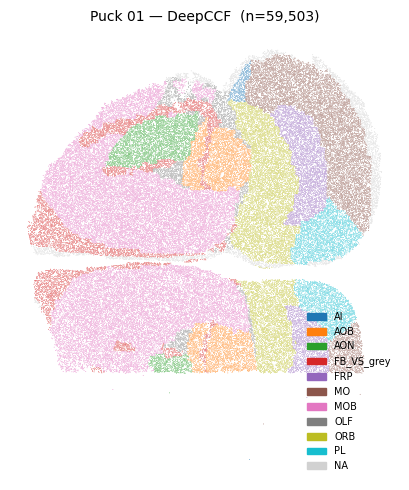

In [21]:
a_puck = pucks[PUCK_IDS[0]]
print(a_puck.columns)
plot_puck(a_puck, PUCK_IDS[0], color = 'DeepCCF')